# MinimaxBot Performance Evaluation

Evaluates `MinimaxBot` at depths 1–4 against `bot_loss-BT` (head-to-head) and then runs a Swiss tournament between all five bots plus `bot_loss-BT`.

In [6]:
import sys
import os

# Walk up from the kernel's cwd until we find the hierarchical-SAE root
# (identified by the presence of a 'bot/' subdirectory).
_dir = os.getcwd()
while not os.path.isdir(os.path.join(_dir, "bot")):
    _parent = os.path.dirname(_dir)
    if _parent == _dir:
        raise RuntimeError(
            "Could not locate hierarchical-SAE root (no 'bot/' folder found)."
        )
    _dir = _parent

ROOT = _dir
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Working directory:", os.getcwd())

Working directory: c:\Users\Jonathan Zea\OneDrive - Escuela Politécnica Nacional\doctorado\hierarchical-SAE


In [5]:
from quartopy import play_games
from bot.minimax_bot import MinimaxBot
from bot.CNN_bot import Quarto_bot
from models.CNN_uncoupled import QuartoCNN as QuartoCNN_uncoupled

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm
from collections import defaultdict
import random

In [13]:
import importlib
import bot.minimax_bot as _mm

importlib.reload(_mm)
from bot.minimax_bot import MinimaxBot

## Bot Instantiation

`bot_loss-BT` is the CNN bot used as the main baseline throughout the project.

In [14]:
# Feasibility note (deepcopy-based minimax, ~100 games per depth):
#   depth 1 → < 1 min  |  depth 2 → ~5 min  |  depth 3 → ~1 h  |  depth 4 → ~4 days
#   depth 6+ → completely infeasible
DEPTHS = [1, 2, 3]  # add 4 if you have several hours to spare
MATCHES_PER_SIDE = 50  # games played per side (total = 2x) for head-to-head
SWISS_ROUNDS = 30  # rounds in the Swiss tournament
GAMES_PER_ROUND = 4  # games per pairing per round (2 as P1 + 2 as P2)
MODE_2X2 = True

# ---- MinimaxBots ----
minimax_bots = {f"Minimax-d{d}": MinimaxBot(depth=d) for d in DEPTHS}

# ---- bot_loss-BT ----
_PATH_LOSS_BT = (
    "CHECKPOINTS//LOSS_APPROACHs_1212-2_only_select//"
    "20251212_2206-LOSS_APPROACHs_1212-2_only_select_E_1034.pt"
)
bot_loss_BT = Quarto_bot(
    model_path=_PATH_LOSS_BT,
    model_class=QuartoCNN_uncoupled,
    deterministic=False,
    temperature=0.1,
)

all_bots: dict = {**minimax_bots, "bot_loss-BT": bot_loss_BT}
print("Bots ready:", list(all_bots.keys()))

Bots ready: ['Minimax-d1', 'Minimax-d2', 'Minimax-d3', 'bot_loss-BT']


## Head-to-Head: Each MinimaxBot Depth vs bot_loss-BT

Each bot plays `MATCHES_PER_SIDE` games as Player 1 and the same as Player 2 against `bot_loss-BT`.

In [15]:
h2h_records = []

for name, bot in tqdm(minimax_bots.items(), desc="Head-to-head"):
    # As Player 1
    _, wr1 = play_games(
        matches=MATCHES_PER_SIDE,
        player1=bot,
        player2=bot_loss_BT,
        verbose=False,
        save_match=False,
        mode_2x2=MODE_2X2,
    )
    # As Player 2
    _, wr2 = play_games(
        matches=MATCHES_PER_SIDE,
        player1=bot_loss_BT,
        player2=bot,
        verbose=False,
        save_match=False,
        mode_2x2=MODE_2X2,
    )

    total = 2 * MATCHES_PER_SIDE
    wins = wr1["Player 1"] + wr2["Player 2"]
    losses = wr1["Player 2"] + wr2["Player 1"]
    draws = wr1["Tie"] + wr2["Tie"]
    win_rate = (wins + 0.5 * draws) / total

    h2h_records.append(
        {
            "bot": name,
            "wins": wins,
            "losses": losses,
            "draws": draws,
            "win_rate": win_rate,
            "total": total,
        }
    )
    print(f"{name:15s}  W={wins:3d}  L={losses:3d}  D={draws:3d}  WR={win_rate:.3f}")

h2h_df = pd.DataFrame(h2h_records).set_index("bot")

Head-to-head:   0%|          | 0/3 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Minimax-d1       W= 57  L= 43  D=  0  WR=0.570


Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Minimax-d2       W= 99  L=  1  D=  0  WR=0.990


Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Minimax-d3       W= 92  L=  8  D=  0  WR=0.920


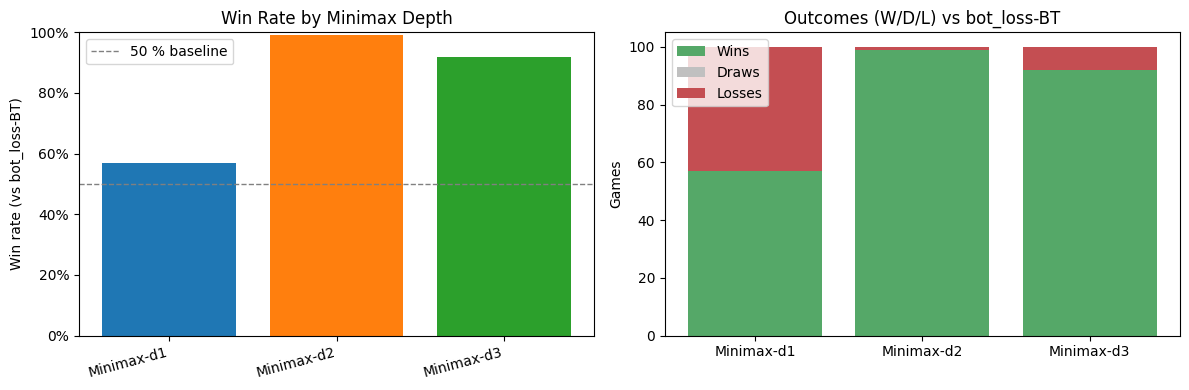

,wins,losses,draws,win_rate,total
bot,,,,,
Minimax-d1,57,43,0,0.57,100
Minimax-d2,99,1,0,0.99,100
Minimax-d3,92,8,0,0.92,100


In [16]:
import matplotlib.cm as cm

n = len(h2h_df)
colors = [cm.tab10(i) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Win rate bar chart
ax = axes[0]
ax.bar(h2h_df.index, h2h_df["win_rate"], color=colors)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="50 % baseline")
ax.set_ylim(0, 1)
ax.set_ylabel("Win rate (vs bot_loss-BT)")
ax.set_title("Win Rate by Minimax Depth")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Stacked W/D/L bar chart
ax2 = axes[1]
x = range(len(h2h_df))
ax2.bar(x, h2h_df["wins"], label="Wins", color="#55A868")
ax2.bar(x, h2h_df["draws"], label="Draws", color="#C0C0C0", bottom=h2h_df["wins"])
ax2.bar(
    x,
    h2h_df["losses"],
    label="Losses",
    color="#C44E52",
    bottom=h2h_df["wins"] + h2h_df["draws"],
)
ax2.set_xticks(list(x))
ax2.set_xticklabels(h2h_df.index)
ax2.set_ylabel("Games")
ax2.set_title("Outcomes (W/D/L) vs bot_loss-BT")
ax2.legend()

plt.tight_layout()
plt.show()
display(h2h_df)

## Round-Robin Tournament

Every bot plays every other bot `MATCHES_PER_SIDE` games as P1 **and** `MATCHES_PER_SIDE` games as P2.  
This gives a complete, unbiased H2H matrix with no pairing artifacts.

In [21]:
from itertools import combinations

rr_records = []  # one entry per ordered pair (a, b) — a's perspective

bot_pairs = list(combinations(all_bots.keys(), 2))
for a_name, b_name in tqdm(bot_pairs, desc="Round-robin"):
    bot_a, bot_b = all_bots[a_name], all_bots[b_name]

    _, wr1 = play_games(
        matches=MATCHES_PER_SIDE,
        player1=bot_a,
        player2=bot_b,
        verbose=False,
        save_match=False,
        mode_2x2=MODE_2X2,
    )
    _, wr2 = play_games(
        matches=MATCHES_PER_SIDE,
        player1=bot_b,
        player2=bot_a,
        verbose=False,
        save_match=False,
        mode_2x2=MODE_2X2,
    )

    total = 2 * MATCHES_PER_SIDE
    a_wins = wr1["Player 1"] + wr2["Player 2"]
    b_wins = wr1["Player 2"] + wr2["Player 1"]
    ties = wr1["Tie"] + wr2["Tie"]
    a_wr = (a_wins + 0.5 * ties) / total

    rr_records.append(
        {
            "bot_a": a_name,
            "bot_b": b_name,
            "a_wins": a_wins,
            "b_wins": b_wins,
            "ties": ties,
            "a_wr": a_wr,
            "b_wr": 1 - a_wr,
            "total": total,
        }
    )
    print(
        f"{a_name:15s} vs {b_name:15s}  "
        f"{a_name}={a_wr:.2%}  {b_name}={(1-a_wr):.2%}"
    )

Round-robin:   0%|          | 0/6 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Minimax-d1      vs Minimax-d2       Minimax-d1=0.00%  Minimax-d2=100.00%


Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

...

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Minimax-d2      vs bot_loss-BT      Minimax-d2=96.00%  bot_loss-BT=4.00%


Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Playing matches...:   0%|          | 0/50 [00:00<?, ?it/s]

Minimax-d3      vs bot_loss-BT      Minimax-d3=85.00%  bot_loss-BT=15.00%


In [22]:
# Build symmetric H2H win-rate matrix
bot_names = list(all_bots.keys())
matrix = pd.DataFrame(index=bot_names, columns=bot_names, dtype=float)
for rec in rr_records:
    matrix.loc[rec["bot_a"], rec["bot_b"]] = rec["a_wr"]
    matrix.loc[rec["bot_b"], rec["bot_a"]] = rec["b_wr"]

# Overall win rate (average across all opponents, weighted by games)
overall_wins = {n: 0 for n in bot_names}
overall_total = {n: 0 for n in bot_names}
for rec in rr_records:
    overall_wins[rec["bot_a"]] += rec["a_wins"] + 0.5 * rec["ties"]
    overall_wins[rec["bot_b"]] += rec["b_wins"] + 0.5 * rec["ties"]
    overall_total[rec["bot_a"]] += rec["total"]
    overall_total[rec["bot_b"]] += rec["total"]

overall_wr = pd.Series(
    {n: overall_wins[n] / overall_total[n] for n in bot_names}, name="overall_win_rate"
).sort_values(ascending=False)

print("=== Overall Win Rate ===")
print(overall_wr.to_string())
print()
print("=== H2H Win-Rate Matrix (row vs column) ===")
display(matrix)

=== Overall Win Rate ===
Minimax-d2     0.820000
Minimax-d3     0.783333
Minimax-d1     0.200000
bot_loss-BT    0.196667

=== H2H Win-Rate Matrix (row vs column) ===


,Minimax-d1,Minimax-d2,Minimax-d3,bot_loss-BT
Minimax-d1,NaN,0.00,0.00,0.60
Minimax-d2,1.0,NaN,0.50,0.96
Minimax-d3,1.0,0.50,NaN,0.85
bot_loss-BT,0.4,0.04,0.15,NaN


## Swiss Tournament Results

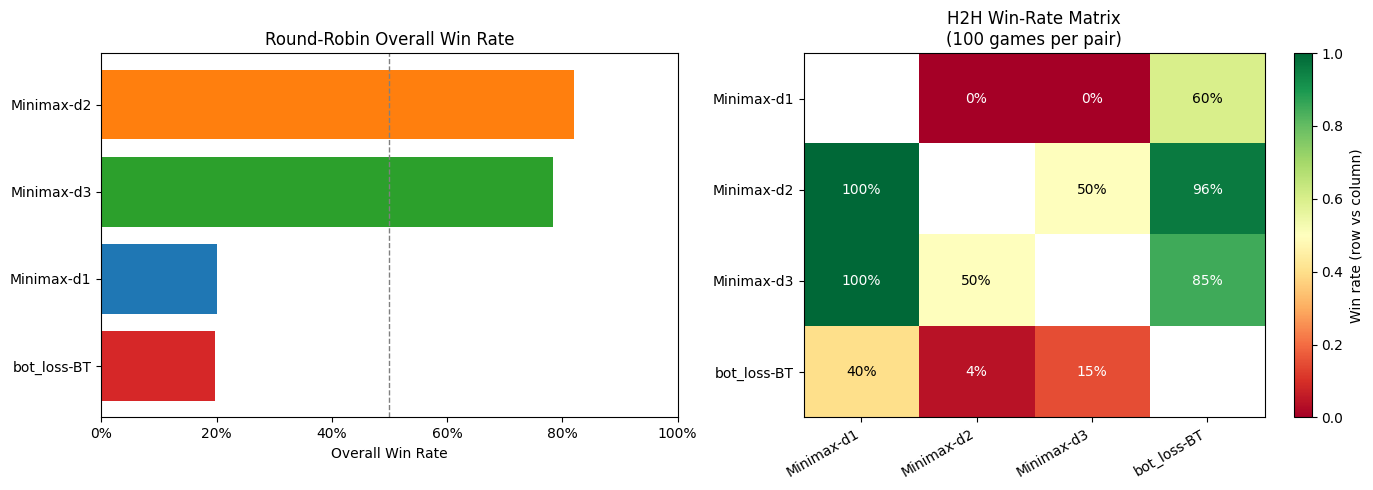

In [23]:
import matplotlib.cm as cm

n_bots = len(bot_names)
tab_colors = {name: cm.tab10(i) for i, name in enumerate(bot_names)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- (1) Overall win rate ----
ax = axes[0]
ax.barh(
    overall_wr.index[::-1],
    overall_wr.values[::-1],
    color=[tab_colors[n] for n in overall_wr.index[::-1]],
)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel("Overall Win Rate")
ax.set_title("Round-Robin Overall Win Rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# ---- (2) H2H heatmap ----
ax2 = axes[1]
mat_vals = matrix.loc[bot_names, bot_names].values.astype(float)
im = ax2.imshow(mat_vals, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax2, label="Win rate (row vs column)")
ax2.set_xticks(range(n_bots))
ax2.set_yticks(range(n_bots))
ax2.set_xticklabels(bot_names, rotation=30, ha="right")
ax2.set_yticklabels(bot_names)
ax2.set_title(f"H2H Win-Rate Matrix\n({2*MATCHES_PER_SIDE} games per pair)")
for i in range(n_bots):
    for j in range(n_bots):
        v = mat_vals[i, j]
        if not pd.isna(v):
            ax2.text(
                j,
                i,
                f"{v:.0%}",
                ha="center",
                va="center",
                fontsize=10,
                color="black" if 0.25 < v < 0.75 else "white",
            )

plt.tight_layout()
plt.show()